# Cognee + LangGraph Integration Guide

This notebook demonstrates how to integrate **Cognee** (a semantic memory for AI agents) with **LangGraph** (an agent orchestration framework) to create AI agents with persistent, cross-session memory capabilities powered by knowledge graphs + embeddings.

## What is Cognee?

**Cognee** is an open-source semantic memory layer that transforms unstructured, structured, semi-strictured data into queryable knowledge graphs backed by embeddings. Cognee:

- **Automatically extracts** entities, relationships, and semantic meaning from text
- **Creates knowledge graphs** with embeddings 
- **Enables natural language queries** to retrieve relevant information
- **Maintains context** across different sessions and interactions
- **Supports multi-modal data** including text, documents, and structured data

## What is LangGraph? 

**LangGraph** is an orchestration framework for complex agentic systems  It provides:

- **State Management**: Persistent conversation state across interactions
- **Tool Integration**: Easy integration with external APIs and services
- **Conditional Routing**: Dynamic flow control based on agent decisions
- **Pre-built Patterns**: Ready-to-use agent architectures like ReAct

## Why Combine Them?

The Cognee-LangGraph integration provides AI agents with persistent, semantic memory that survives between sessions. Agents can store information in Cognee's knowledge graph and retrieve it using natural language queries, enabling more accurate retrieval, continuity across conversations without manual state management.

Let's explore how this works in practice!


## 📋 Prerequisites

This guide uses Wikipedia for external knowledge retrieval, which is included in the standard installation.

To run this notebook:

```bash
# Sync all dependencies
uv sync --group guide
```

Or if you're using pip:

```bash
# Install the package
pip install cognee-integration-langgraph
```

**Note**: The Wikipedia tool is included in the base `langchain-community` package that comes with the integration.

## Environment Setup

Both LangGraph and Cognee require an OpenAI API key for LLM operations (You can swap providers later; the graph logic stays the same.) Let's configure the environment:


In [ ]:
import os

# Set your environment variables here or in your .env file
# Get your API key from: https://platform.openai.com/api-keys
# For more configuration options, see: https://docs.cognee.ai/setup-configuration/overview

os.environ["OPENAI_API_KEY"] = "YOUR-OPENAI-API-KEY-HERE"
os.environ["LLM_API_KEY"] = os.environ["OPENAI_API_KEY"]
os.environ["CACHING"] = "true"
os.environ["CACHE_BACKEND"] = "fs"

## LangGraph Fundamentals

Before diving into the Cognee integration, let's understand LangGraph's core building blocks:

### State Management
**State** defines what information flows through your graph. LangGraph uses TypedDict to define structured state that persists across nodes.

### Nodes 
**Nodes** are functions that process state and return updates. Each node receives the current state and can modify it.

### Edges
**Edges** define how information flows between nodes. They can be:
- **Simple**: Direct connections (A → B)
- **Conditional**: Dynamic routing based on state content

As an example, we’ll define a tiny state (a list of messages), initialize a chat model, and create a single chatbot node that appends the LLM’s reply to the message list.

In [2]:
from typing import Annotated, TypedDict

from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

llm = init_chat_model("openai:gpt-4.1")


def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

### Connecting the Graph

Now we need to connect our nodes with edges to create a complete execution flow:

- **START**: Entry point for the graph
- **END**: Exit point for the graph  
- **Edges**: Define the path from START → chatbot → END

This creates a linear flow where every message goes through our chatbot node:

In [3]:
from langgraph.graph import END, START

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

### How does the LangGraph look like right now?

Let's visualize our simple chatbot graph to understand the flow:

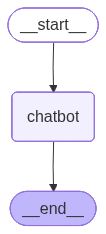

In [4]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [5]:
graph.get_graph().print_ascii()

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | chatbot |   
 +---------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


### Testing the Basic Chatbot

Let's create a helper function to interact with our graph and test it with a simple question:

In [6]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


stream_graph_updates("what is the capital of Argentina?")

Assistant: The capital of Argentina is **Buenos Aires**.


## Adding Tools to LangGraph

Our current chatbot can only chat - it has no access to external information. Let's add **tools** to give it real capabilities!

### Wikipedia Tool Integration

We'll use LangChain's Wikipedia tool to give our agent access to knowledge from Wikipedia.

Let's test the tool directly first:

In [7]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

print(wikipedia_tool.run("Alan Turing"))

Page: Alan Turing
Summary: Alan Mathison Turing (; 23 June 1912 – 7 June 1954) was an English mathematician, computer scientist, logician, cryptanalyst, philosopher and theoretical biologist. He was highly influential in the development of theoretical computer science, providing a formalisation of the concepts of algorithm and computation with the Turing machine, which can be considered a model of a general-purpose computer. Turing is widely considered to be the father of theoretical computer science.
Born in London, Turing was raised in southern England. He graduated from King's College, Cambridge, and in 1938, earned a doctorate degree from Princeton University. During World War II, Turing worked for the Government Code and Cypher School at Bletchley Park, Britain's codebreaking centre that produced Ultra intelligence. He led Hut 8, the section responsible for German naval cryptanalysis. Turing devised techniques for speeding the breaking of German ciphers, including improvements to 

### Creating a Tool Node

To integrate tools into our LangGraph, we need a **tool node** that can:

1. **Receive tool calls** from the LLM
2. **Execute the requested tools** with provided arguments  
3. **Return results** back to the conversation flow

This node acts as a bridge between the LLM's tool calling capabilities and actual tool execution:

In [8]:
import json

from langchain_core.messages import ToolMessage


class BasicToolNode:
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        print("calling basic tool node...")
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No messages found in inputs")
        outputs = []
        for tool_call in message.tool_calls:
            print(f"tool {tool_call} being processed...")
            tool_result = self.tools_by_name[tool_call["name"]].invoke(tool_call["args"])
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}

### Updating the Chatbot for Tools

Now we need to make several updates to enable tool usage:

1. **Create tool node instance** with our Wikipedia tool
2. **Bind tools to the LLM** so it knows what tools are available
3. **Update the chatbot node** to use the tool-enabled LLM

The `bind_tools()` method tells the LLM about available tools and their schemas, enabling it to generate proper tool calls:

In [9]:
tools = [wikipedia_tool]
tool_node = BasicToolNode(tools)

llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

### Plugging into LangGraph

Now we need **conditional routing** to decide when to use tools. The LLM might:
- **Answer directly** (no tools needed) → go to END
- **Make tool calls** (tools needed) → go to tools node

We need a **routing function** that examines the LLM's response and decides the next step:



In [10]:
def route_tools(state: State):
    if messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError("No messages found in inputs")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"

    return END

### Building the Tool-Enabled Graph

Now let's assemble all the pieces into a complete graph:

1. **Add chatbot node** (with tool-enabled LLM)
2. **Add tools node** (for executing tools)  
3. **Add conditional edge** (chatbot → tools OR END)
4. **Add return edge** (tools → chatbot for follow-up)

This creates a **ReAct pattern**: Reasoning → Acting → Observing → Reasoning...

In [11]:
graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")

graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {"tools": "tools", END: END},
)

graph_builder.add_edge("tools", "chatbot")

graph = graph_builder.compile()

### Enchanced Graph

Our graph now has more complexity! Notice:
- **New tools node** for executing external tools
- **Conditional edge** that can route to either tools or END  
- **Cycle back** from tools to chatbot for processing results

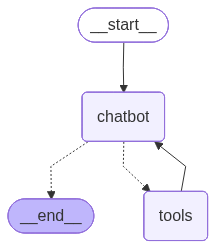

In [12]:
Image(graph.get_graph().draw_mermaid_png())

In [13]:
graph.get_graph().print_ascii()

        +-----------+         
        | __start__ |         
        +-----------+         
               *              
               *              
               *              
          +---------+         
          | chatbot |         
          +---------+         
          .         *         
        ..           **       
       .               *      
+---------+         +-------+ 
| __end__ |         | tools | 
+---------+         +-------+ 


### Testing the Tool-Enabled Agent

Let's test our enhanced graph with a query that should trigger the Wikipedia tool.

In [14]:
stream_graph_updates("Alan Turing")

Assistant: 
calling basic tool node...
tool {'name': 'wikipedia', 'args': {'query': 'Alan Turing'}, 'id': 'call_QyDYGdrgdKqmzH9q029p0bTE', 'type': 'tool_call'} being processed...
Assistant: "Page: Alan Turing\nSummary: Alan Mathison Turing (; 23 June 1912 \u2013 7 June 1954) was an English mathematician, computer scientist, logician, cryptanalyst, philosopher and theoretical biologist. He was highly influential in the development of theoretical computer science, providing a formalisation of the concepts of algorithm and computation with the Turing machine, which can be considered a model of a general-purpose computer. Turing is widely considered to be the father of theoretical computer science.\nBorn in London, Turing was raised in southern England. He graduated from King's College, Cambridge, and in 1938, earned a doctorate degree from Princeton University. During World War II, Turing worked for the Government Code and Cypher School at Bletchley Park, Britain's codebreaking centre tha

## Introducing Cognee to LangGraph: Semantic Memory for Agents

Now let's add **persistent semantic memory** to our agents using Cognee! 

### What Cognee Adds to LangGraph:

- **Semantic Memory**: Store and retrieve information using natural language from cognee's knowledge graph backed by embeddings
- **Knowledge Graphs**: Automatic entity and relationship extraction  
- **Cross-Session Persistence**: Memory survives between different agent instances
- **Intelligent Search**: Find relevant information by meaning using cognee's advanced retrieval methods
- **Session Isolation**: Keep different users' data separate and secure

### Cognee Tools Integration

The integration provides two main tools:
- **`add_tool`**: Store information in Cognee's knowledge graph
- **`search_tool`**: Query stored information using natural language

Let's configure Cognee and see it in action:


In [15]:
# Before we start using cognee, we need to define a few env variables for cognee
os.environ["LLM_API_KEY"] = os.environ["OPENAI_API_KEY"]
os.environ["ENABLE_BACKEND_ACCESS_CONTROL"] = "false"

In [16]:
from langchain.agents import create_agent

from cognee_integration_langgraph import add_tool, search_tool

agent = create_agent(
    "openai:gpt-4o-mini",
    tools=[
        add_tool,
        search_tool,
    ],
)
agent.step_timeout = None


2026-03-13T08:40:11.938697 [warning  ] From version 0.5.0 onwards, Cognee will run with multi-user access control mode set to on by default. Data isolation between different users and datasets will be enforced and data created before multi-user access control mode was turned on won't be accessible by default. To disable multi-user access control mode and regain access to old data set the environment variable ENABLE_BACKEND_ACCESS_CONTROL to false before starting Cognee. For more information, please refer to the Cognee documentation. [cognee.shared.logging_utils]

2026-03-13T08:40:11.939206 [info     ] Log file created at: /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/.venv/lib/python3.10/site-packages/logs/2026-03-13_09-40-11.log [cognee.shared.logging_utils] log_file=/Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/.venv/lib/python3.10/site-packages/logs/2026-03-13_09-40-11.log

2026-03-13T08:40:11.939503 [info   

You can see in the diagram that it's essentially the same graph

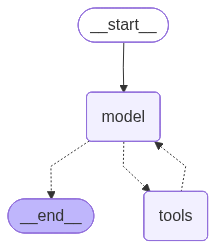

In [17]:
Image(agent.get_graph().draw_mermaid_png())

Also, let's run pruning - so that we know we're starting from a clean slate state

In [18]:
import cognee

await cognee.prune.prune_data()
await cognee.prune.prune_system(metadata=True)


2026-03-13T08:40:16.163258 [info     ] Loaded JSON extension          [cognee.shared.logging_utils]

2026-03-13T08:40:16.187331 [info     ] Deleted Kuzu database files at /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/.venv/lib/python3.10/site-packages/cognee/.cognee_system/databases/cognee_graph_kuzu [cognee.shared.logging_utils]

2026-03-13T08:40:19.173309 [info     ] Database deleted successfully. [cognee.shared.logging_utils]

Storage manager absolute path: /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/.venv/lib/python3.10/site-packages/cognee/.cognee_cache

Deleting cache...             

✓ Cache deleted successfully! 


### Background Data Ingestion

Now let's add some additional data directly to Cognee (bypassing the agent) to demonstrate how the agent can access pre-existing knowledge:

This simulates a scenario where:
- **Historical data** exists in the knowledge base
- **Agent interactions** add new information  
- **Both sources** are searchable together

The agent will be able to search across all this information seamlessly:


Let's give our agent a set of inputs that it can memorize in Cognee

In [19]:
from langchain_core.messages import HumanMessage

response = await agent.ainvoke(
    {
        "messages": [
            HumanMessage(
                content="""
                We have signed a contract with the following company: "Meditech Solutions". Company is in the healthcare industry. Start date is Jan 2023 and end date is Dec 2025. Contract value is £1.2M.
            """
            ),
            HumanMessage(
                content="""
                We have signed a contract with the following company: "QuantumSoft". Company is in the technology industry. Start date is Aug 2024 and end date is Aug 2028. Contract value is £5.5M.
            """
            ),
            HumanMessage(
                content="""
                We have signed a contract with the following company: "Orion Retail Group". Company is in the retail industry. Start date is Mar 2024 and end date is Mar 2026. Contract value is £850K.
            """
            ),
        ],
    }
)


print("=== FIRST RESPONSE ===")
print(response["messages"][-1].content)


Adding data to cognee: Signed contract with Meditech Solutions; Industry: healthcare; Start date: Jan 2023; End date: Dec 2025; Contract value: £1.2M.

Adding data to cognee: Signed contract with QuantumSoft; Industry: technology; Start date: Aug 2024; End date: Aug 2028; Contract value: £5.5M.

Adding data to cognee: Signed contract with Orion Retail Group; Industry: retail; Start date: Mar 2024; End date: Mar 2026; Contract value: £850K.

2026-03-13T08:40:23.284213 [info     ] Testing connection to LLM endpoint... [cognee.shared.logging_utils]


User 79d8c070-58b4-48fa-87c4-bf12d4b64d81 has registered.



2026-03-13T08:40:36.027183 [info     ] Testing connection to Embedding endpoint... [cognee.shared.logging_utils]

2026-03-13T08:40:36.370400 [info     ] Pipeline run started: `ed22c412-bb8c-5ecc-923a-af719eedbf85` [run_tasks_with_telemetry()]

2026-03-13T08:40:36.588356 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-03-13T08:40:36.799813 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-03-13T08:40:37.044238 [info     ] Registered loader: pypdf_loader [cognee.infrastructure.loaders.LoaderEngine]

2026-03-13T08:40:37.044783 [info     ] Registered loader: text_loader [cognee.infrastructure.loaders.LoaderEngine]

2026-03-13T08:40:37.045071 [info     ] Registered loader: image_loader [cognee.infrastructure.loaders.LoaderEngine]

2026-03-13T08:40:37.045275 [info     ] Registered loader: audio_loader [cognee.infrastructure.loaders.LoaderEngine]

2026-03-13T08:40:37.045558 [info     ] Registered loader: csv_loader  [cognee.infrast

=== FIRST RESPONSE ===
The contracts with the following companies have been successfully stored:

1. **Meditech Solutions**
   - Industry: Healthcare
   - Start Date: January 2023
   - End Date: December 2025
   - Contract Value: £1.2M

2. **QuantumSoft**
   - Industry: Technology
   - Start Date: August 2024
   - End Date: August 2028
   - Contract Value: £5.5M

3. **Orion Retail Group**
   - Industry: Retail
   - Start Date: March 2024
   - End Date: March 2026
   - Contract Value: £850K

If you need any further information or assistance, feel free to ask!


Cool!

Let's also add some data into our knowledge graph (bypassing the agent).

In [20]:
agent.step_timeout = None

data_dir = os.path.join(os.getcwd(), "data")
for filename in os.listdir(data_dir):
    if filename.endswith(".txt"):
        file_path = os.path.join(data_dir, filename)
        with open(file_path, "r") as f:
            content = f.read()
            await cognee.add(content)
await cognee.cognify()


2026-03-13T08:42:12.411652 [info     ] Pipeline run started: `ed22c412-bb8c-5ecc-923a-af719eedbf85` [run_tasks_with_telemetry()]

2026-03-13T08:42:12.603963 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-03-13T08:42:12.809242 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-03-13T08:42:13.062768 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-03-13T08:42:13.265666 [info     ] Coroutine task completed: `resolve_data_directories` [run_tasks_base]

2026-03-13T08:42:13.471739 [info     ] Pipeline run completed: `ed22c412-bb8c-5ecc-923a-af719eedbf85` [run_tasks_with_telemetry()]

2026-03-13T08:42:13.698307 [info     ] No ontology file provided. No owl ontology will be attached to the graph. [OntologyAdapter]

2026-03-13T08:42:13.738505 [info     ] Pipeline run started: `fb917c7c-1f1b-5ca9-9e64-17cc1e724aae` [run_tasks_with_telemetry()]

2026-03-13T08:42:13.935576 [info     ] Coroutine task started: `c

{UUID('66811d9d-7b54-56a7-9072-5e40e3308f8c'): PipelineRunCompleted(status='PipelineRunCompleted', pipeline_run_id=UUID('ae8a7978-c361-58c1-a48c-b56fad859679'), dataset_id=UUID('66811d9d-7b54-56a7-9072-5e40e3308f8c'), dataset_name='main_dataset', payload=None, data_ingestion_info=[{'run_info': PipelineRunCompleted(status='PipelineRunCompleted', pipeline_run_id=UUID('ae8a7978-c361-58c1-a48c-b56fad859679'), dataset_id=UUID('66811d9d-7b54-56a7-9072-5e40e3308f8c'), dataset_name='main_dataset', payload=None, data_ingestion_info=None), 'data_id': UUID('c3c185c1-7710-5a94-b8ec-880987722392')}, {'run_info': PipelineRunAlreadyCompleted(status='PipelineRunAlreadyCompleted', pipeline_run_id=UUID('ae8a7978-c361-58c1-a48c-b56fad859679'), dataset_id=UUID('66811d9d-7b54-56a7-9072-5e40e3308f8c'), dataset_name='main_dataset', payload=None, data_ingestion_info=None), 'data_id': UUID('85fd91c5-21c4-5022-b6f7-b611182c4d49')}, {'run_info': PipelineRunAlreadyCompleted(status='PipelineRunAlreadyCompleted', p

### Let's visualize the graph from cognee

In [21]:
import webbrowser


async def visualize_graph(file_name, open_browser=True):
    destination_file_path = os.path.join(os.getcwd(), file_name)

    await cognee.visualize_graph(destination_file_path)

    if open_browser:
        url = "file://" + os.path.abspath(destination_file_path)
        webbrowser.open(url)


await visualize_graph(file_name="graph_visualization/first_graph_visualization.html")


2026-03-13T08:45:12.362203 [info     ] Retrieved 83 nodes and 195 edges in 0.01 seconds [cognee.shared.logging_utils]

2026-03-13T08:45:12.365942 [info     ] Graph visualization saved as /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/examples/graph_visualization/first_graph_visualization.html [cognee.shared.logging_utils]

2026-03-13T08:45:12.366405 [info     ] The HTML file has been stored at path: /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/examples/graph_visualization/first_graph_visualization.html [cognee.shared.logging_utils]


From the specified path above, open the `first_graph_visualization.html` in your browser (if not automatically opened). You can see clients.txt subgraph and input from LangGraph agent interactions distinctly. 

## Cross-Session Memory Persistence

Now let's demonstrate one of Cognee's key features: **persistent memory across agent instances**.

We'll create a completely fresh agent instance that:
- Has **no conversation history** from the previous agent
- Has **no internal state** carried over  
- **CAN access** all information stored in Cognee's knowledge graph

This shows how Cognee provides **true persistent memory** that survives agent restarts:


In [23]:
# Create a fresh agent instance to avoid memory interference
fresh_agent = create_agent(
    "openai:gpt-4o-mini",
    tools=[
        add_tool,
        search_tool,
    ],
)
# Note: LangGraph by default can retry running tools if it considers it's running too long, so we're explicitly setting timeout to None so it doesn't retry
agent.step_timeout = None

response = await fresh_agent.ainvoke(
    {
        "messages": [
            HumanMessage(
                content="I need to research our contract portfolio. Can you search for any contracts we have with companies in the healthcare industry? Please use the search functionality to find this information."
            ),
        ],
    }
)
print("\n=== SECOND RESPONSE ===")
print(response["messages"][-1].content)


Searching cognee for: contracts with companies in the healthcare industry with session_id: None, node_set: None, query_type: None

2026-03-13T08:45:14.740143 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 0.38s [cognee.shared.logging_utils]

2026-03-13T08:45:14.740827 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-03-13T08:45:14.747761 [info     ] ID-filtered retrieval: 83 nodes and 195 edges in 0.01s [cognee.shared.logging_utils]

2026-03-13T08:45:14.750832 [info     ] Graph projection completed: 83 nodes, 195 edges in 0.00s [CogneeGraph]

2026-03-13T08:45:14.754937 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 71, 'connection_count': 100}

Search results: ['- HealthBridge Systems — Feb 2023 to Jan 2026 — £2.4M\n- NovaCare Diagnostics — May 2024 to Apr 2027 — £1.6M\n- Meditech Solutions — Jan 2023 to Dec 2025 — £1.2M']



=== SECOND RESPONSE ===
Here are the contracts we have with companies in the healthcare industry:

1. **HealthBridge Systems**  
   - Duration: February 2023 to January 2026  
   - Value: £2.4M

2. **NovaCare Diagnostics**  
   - Duration: May 2024 to April 2027  
   - Value: £1.6M

3. **Meditech Solutions**  
   - Duration: January 2023 to December 2025  
   - Value: £1.2M


## Sessions with Cognee

Let's say we want to add our own, custom state into LangGraph.

There are two possible ways to consider:
1. Define a wrapper around `create_agent`
2. Define tools such that they know the state

To minimize confusion, we define tools such that they know the state.

```python
def get_sessionized_cognee_tools(user_id: str) -> list:
    """
    Returns a list of cognee tools sessionized for a specific user.
    
    Args:
        user_id (str): The user session ID to bind to all tools
        
    Returns:
        list: List of sessionized cognee tools
    """
    session_decorator = sessionised_tool(user_id)
    
    sessionized_add_tool = tool(session_decorator(add_tool.func))
    sessionized_search_tool = tool(session_decorator(search_tool.func))
    
    return [
        sessionized_add_tool,
        sessionized_search_tool,
    ]
```

In [24]:
# Let's start with a clean slate

await cognee.prune.prune_data()
await cognee.prune.prune_system(metadata=True)


2026-03-13T08:45:36.157101 [info     ] Deleted Kuzu database files at /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/.venv/lib/python3.10/site-packages/cognee/.cognee_system/databases/cognee_graph_kuzu [cognee.shared.logging_utils]

2026-03-13T08:45:38.193057 [info     ] Database deleted successfully. [cognee.shared.logging_utils]

Deleting cache...             

✓ Cache deleted successfully! 


In [25]:
from cognee_integration_langgraph import get_sessionized_cognee_tools

add_tool, search_tool = get_sessionized_cognee_tools()

super_fresh_agent = create_agent(
    "openai:gpt-4o-mini",
    tools=[
        add_tool,
        search_tool,
    ],
)

super_fresh_agent.step_timeout = None

response = await super_fresh_agent.ainvoke(
    {
        "messages": [
            HumanMessage(
                content="""
                We have signed a contract with the following company: "Guardian Insurance Ltd". Company is in the insurance industry. Start date is Feb 2023 and end date is Feb 2026. Contract value is £1.8M.
            """
            ),
            HumanMessage(
                content="""
                We have signed a contract with the following company: "Pioneer Assurance Group". Company is in the insurance industry. Start date is Oct 2024 and end date is Oct 2029. Contract value is £4.2M.
            """
            ),
            HumanMessage(
                content="""
                We have signed a contract with the following company: "Finovate Systems". Company is in the fintech industry. Start date is May 2024 and end date is May 2027. Contract value is £2.3M.
            """
            ),
        ],
    }
)

print("=== FIRST RESPONSE ===")
print(response["messages"][-1].content)


Initialized session with session_id = cognee-test-user-a8159319-ac40-482d-8687-c0183ddb4bf1

Using tool add_tool with session_id: cognee-test-user-a8159319-ac40-482d-8687-c0183ddb4bf1

Adding data to cognee: Signed contract with Guardian Insurance Ltd. Industry: Insurance. Start date: Feb 2023, End date: Feb 2026, Contract value: £1.8M.

Using tool add_tool with session_id: cognee-test-user-a8159319-ac40-482d-8687-c0183ddb4bf1

Adding data to cognee: Signed contract with Pioneer Assurance Group. Industry: Insurance. Start date: Oct 2024, End date: Oct 2029, Contract value: £4.2M.

Using tool add_tool with session_id: cognee-test-user-a8159319-ac40-482d-8687-c0183ddb4bf1

Adding data to cognee: Signed contract with Finovate Systems. Industry: Fintech. Start date: May 2024, End date: May 2027, Contract value: £2.3M.

2026-03-13T08:45:41.390676 [info     ] Pipeline run started: `a140f293-ed2c-57a2-8d95-6cc126884ea0` [run_tasks_with_telemetry()]


User 2eb389c0-f156-4243-b95b-3687b5cf650e has registered.



2026-03-13T08:45:41.606682 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-03-13T08:45:41.809860 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-03-13T08:45:42.066951 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-03-13T08:45:42.256514 [info     ] Coroutine task completed: `resolve_data_directories` [run_tasks_base]

2026-03-13T08:45:42.463741 [info     ] Pipeline run completed: `a140f293-ed2c-57a2-8d95-6cc126884ea0` [run_tasks_with_telemetry()]

2026-03-13T08:45:42.791217 [info     ] Pipeline run started: `a140f293-ed2c-57a2-8d95-6cc126884ea0` [run_tasks_with_telemetry()]

2026-03-13T08:45:42.981848 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-03-13T08:45:43.167962 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-03-13T08:45:43.524386 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-03-13T08:45:43.716057 

=== FIRST RESPONSE ===
The contracts have been successfully recorded:

1. **Guardian Insurance Ltd**: 
   - Industry: Insurance
   - Start Date: Feb 2023 
   - End Date: Feb 2026 
   - Contract Value: £1.8M

2. **Pioneer Assurance Group**: 
   - Industry: Insurance
   - Start Date: Oct 2024 
   - End Date: Oct 2029 
   - Contract Value: £4.2M

3. **Finovate Systems**: 
   - Industry: Fintech
   - Start Date: May 2024 
   - End Date: May 2027 
   - Contract Value: £2.3M

If you need further assistance, just let me know!


Let's add one more input, but not as part of the session - and see how it renders!

In [ ]:
await cognee.add(
    'We have signed a contract with the following company: "Pied Piper Technologies". Company is in the fintech industry. Start date is Jan 2025 and end date is Jan 2028. Contract value is £3.1M.'
)
await cognee.cognify()


2026-03-13T08:49:39.948372 [info     ] Pipeline run started: `a140f293-ed2c-57a2-8d95-6cc126884ea0` [run_tasks_with_telemetry()]

2026-03-13T08:49:40.169803 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-03-13T08:49:40.399290 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-03-13T08:49:40.655856 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-03-13T08:49:40.854390 [info     ] Coroutine task completed: `resolve_data_directories` [run_tasks_base]

2026-03-13T08:49:41.078634 [info     ] Pipeline run completed: `a140f293-ed2c-57a2-8d95-6cc126884ea0` [run_tasks_with_telemetry()]

2026-03-13T08:49:41.308538 [info     ] No ontology file provided. No owl ontology will be attached to the graph. [OntologyAdapter]

2026-03-13T08:49:41.354484 [info     ] Pipeline run started: `4125ce04-8c3e-5756-bb3f-56aaf534fd0c` [run_tasks_with_telemetry()]

2026-03-13T08:49:41.572870 [info     ] Coroutine task started: `c

### Session Clustering Analysis

In this visualization, you can clearly observe **session-based data clustering**:

1. **Session Cluster**: All data processed within our specific session is grouped together around the session identifier
2. **Global Data**: Information added outside the session forms a separate cluster  
3. **Clean Separation**: The two data groups remain distinct while still being part of the same knowledge graph

This demonstrates how Cognee maintains both **session isolation** and **global knowledge accessibility**.


In [ ]:
await visualize_graph(file_name="graph_visualization/second_graph_visualization_sessionised.html")


2026-03-13T09:09:13.811536 [info     ] Retrieved 41 nodes and 94 edges in 0.03 seconds [cognee.shared.logging_utils]

2026-03-13T09:09:13.816126 [info     ] Graph visualization saved as /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/examples/final_graph_visualization_custom_sessionized.html [cognee.shared.logging_utils]

2026-03-13T09:09:13.816730 [info     ] The HTML file has been stored at path: /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/examples/final_graph_visualization_custom_sessionized.html [cognee.shared.logging_utils]


## New Session Management: Native session_id Support

Cognee now supports **native session management** through the `session_id` parameter. This allows for better conversation context tracking and the ability to persist sessions into the knowledge graph for long-term memory.

### Key Features:
1. **Native session_id**: Pass `session_id` directly to search queries for conversation context
2. **Session Persistence**: Convert conversation sessions into permanent knowledge graph nodes  
3. **Cross-Session Learning**: Sessions can reference each other once persisted

Let's demonstrate this new approach!

In [2]:
import cognee

# Clean slate for the new session demo
await cognee.prune.prune_data()
await cognee.prune.prune_system(metadata=True)

# Add some initial knowledge
text_1 = (
    "Cognee is a solution that can build knowledge graphs from text, creating an AI memory system"
)
text_2 = "Germany is a country located next to the Netherlands"

await cognee.add([text_1, text_2])
await cognee.cognify()

print("✓ Initial knowledge added to Cognee")


2026-03-13T09:28:17.258854 [warning  ] From version 0.5.0 onwards, Cognee will run with multi-user access control mode set to on by default. Data isolation between different users and datasets will be enforced and data created before multi-user access control mode was turned on won't be accessible by default. To disable multi-user access control mode and regain access to old data set the environment variable ENABLE_BACKEND_ACCESS_CONTROL to false before starting Cognee. For more information, please refer to the Cognee documentation. [cognee.shared.logging_utils]

2026-03-13T09:28:17.259516 [info     ] Log file created at: /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/.venv/lib/python3.10/site-packages/logs/2026-03-13_10-28-16.log [cognee.shared.logging_utils] log_file=/Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/.venv/lib/python3.10/site-packages/logs/2026-03-13_10-28-16.log

2026-03-13T09:28:17.259761 [info   

User 8b61ae18-6da3-4bef-96dc-947e07e188de has registered.



2026-03-13T09:28:29.652687 [info     ] Testing connection to Embedding endpoint... [cognee.shared.logging_utils]

2026-03-13T09:28:30.111194 [info     ] Pipeline run started: `c4901e60-cedb-50db-9276-c45a23b994c4` [run_tasks_with_telemetry()]

2026-03-13T09:28:30.313651 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-03-13T09:28:30.511048 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-03-13T09:28:30.780866 [info     ] Pipeline run started: `c4901e60-cedb-50db-9276-c45a23b994c4` [run_tasks_with_telemetry()]

2026-03-13T09:28:30.993368 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-03-13T09:28:31.193380 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-03-13T09:28:31.410842 [info     ] Registered loader: pypdf_loader [cognee.infrastructure.loaders.LoaderEngine]

2026-03-13T09:28:31.411228 [info     ] Registered loader: text_loader [cognee.infrastructure.loaders.L

✓ Initial knowledge added to Cognee


In [3]:
from cognee.modules.search.types import SearchType

print("=" * 80)
print("SESSION 1: Conversation about Cognee")
print("=" * 80)

# First question in session 1
question = "What can I use to create a knowledge graph?"
search_results = await cognee.search(
    query_type=SearchType.GRAPH_COMPLETION, query_text=question, session_id="session_1"
)
print(f"\nQuestion: {question}")
print(f"Answer: {search_results}\n")

# Follow-up question in session 1 (maintains context!)
question = "You sure about that?"
search_results = await cognee.search(
    query_type=SearchType.GRAPH_COMPLETION, query_text=question, session_id="session_1"
)
print(f"Follow-up Question: {question}")
print(f"Answer: {search_results}\n")

# Another follow-up
question = "This is awesome!"
search_results = await cognee.search(
    query_type=SearchType.GRAPH_COMPLETION, query_text=question, session_id="session_1"
)
print(f"Follow-up Question: {question}")
print(f"Answer: {search_results}\n")

SESSION 1: Conversation about Cognee



2026-03-13T09:29:54.365263 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 0.21s [cognee.shared.logging_utils]

2026-03-13T09:29:54.365867 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-03-13T09:29:54.373349 [info     ] ID-filtered retrieval: 15 nodes and 20 edges in 0.01s [cognee.shared.logging_utils]

2026-03-13T09:29:54.374116 [info     ] Graph projection completed: 15 nodes, 20 edges in 0.00s [CogneeGraph]

2026-03-13T09:29:54.375252 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 8, 'connection_count': 10}



Question: What can I use to create a knowledge graph?
Answer: [{'dataset_id': UUID('2c78d2f5-97f7-510f-9114-d227b8d73340'), 'dataset_name': 'main_dataset', 'dataset_tenant_id': None, 'search_result': ['Cognee—it converts text into knowledge graphs to build an AI memory system.']}]




2026-03-13T09:30:03.492247 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 0.43s [cognee.shared.logging_utils]

2026-03-13T09:30:03.496871 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-03-13T09:30:03.503267 [info     ] ID-filtered retrieval: 15 nodes and 20 edges in 0.00s [cognee.shared.logging_utils]

2026-03-13T09:30:03.506601 [info     ] Graph projection completed: 15 nodes, 20 edges in 0.00s [CogneeGraph]

2026-03-13T09:30:03.510967 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 11, 'connection_count': 10}


Follow-up Question: You sure about that?
Answer: [{'dataset_id': UUID('2c78d2f5-97f7-510f-9114-d227b8d73340'), 'dataset_name': 'main_dataset', 'dataset_tenant_id': None, 'search_result': ['Yes—per the context, Cognee builds knowledge graphs from text and creates an AI memory system.']}]




2026-03-13T09:30:11.000193 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 0.28s [cognee.shared.logging_utils]

2026-03-13T09:30:11.000977 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-03-13T09:30:11.004191 [info     ] ID-filtered retrieval: 15 nodes and 20 edges in 0.00s [cognee.shared.logging_utils]

2026-03-13T09:30:11.004851 [info     ] Graph projection completed: 15 nodes, 20 edges in 0.00s [CogneeGraph]

2026-03-13T09:30:11.006212 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 9, 'connection_count': 10}


Follow-up Question: This is awesome!
Answer: [{'dataset_id': UUID('2c78d2f5-97f7-510f-9114-d227b8d73340'), 'dataset_name': 'main_dataset', 'dataset_tenant_id': None, 'search_result': ['Thanks! Cognee converts text into knowledge graphs to create an AI memory system.']}]



In [4]:
print("=" * 80)
print("SESSION 2: Different conversation about Germany")
print("=" * 80)

# First question in session 2
question = "Where is Germany?"
search_results = await cognee.search(
    query_type=SearchType.GRAPH_COMPLETION, query_text=question, session_id="session_2"
)
print(f"\nQuestion: {question}")
print(f"Answer: {search_results}\n")

# Follow-up question in session 2 (maintains its own context)
question = "Next to which country again?"
search_results = await cognee.search(
    query_type=SearchType.GRAPH_COMPLETION, query_text=question, session_id="session_2"
)
print(f"Follow-up Question: {question}")
print(f"Answer: {search_results}\n")

# Another follow-up in session 2
question = "So you remember everything I asked from you?"
search_results = await cognee.search(
    query_type=SearchType.GRAPH_COMPLETION, query_text=question, session_id="session_2"
)
print(f"Follow-up Question: {question}")
print(f"Answer: {search_results}\n")

SESSION 2: Different conversation about Germany



2026-03-13T09:30:19.166532 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 0.68s [cognee.shared.logging_utils]

2026-03-13T09:30:19.167177 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-03-13T09:30:19.169962 [info     ] ID-filtered retrieval: 15 nodes and 20 edges in 0.00s [cognee.shared.logging_utils]

2026-03-13T09:30:19.170515 [info     ] Graph projection completed: 15 nodes, 20 edges in 0.00s [CogneeGraph]

2026-03-13T09:30:19.171975 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 11, 'connection_count': 10}



Question: Where is Germany?
Answer: [{'dataset_id': UUID('2c78d2f5-97f7-510f-9114-d227b8d73340'), 'dataset_name': 'main_dataset', 'dataset_tenant_id': None, 'search_result': ['Germany is located next to the Netherlands.']}]




2026-03-13T09:30:23.712256 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 0.33s [cognee.shared.logging_utils]

2026-03-13T09:30:23.713027 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-03-13T09:30:23.716450 [info     ] ID-filtered retrieval: 15 nodes and 20 edges in 0.00s [cognee.shared.logging_utils]

2026-03-13T09:30:23.717079 [info     ] Graph projection completed: 15 nodes, 20 edges in 0.00s [CogneeGraph]

2026-03-13T09:30:23.718907 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 11, 'connection_count': 10}


Follow-up Question: Next to which country again?
Answer: [{'dataset_id': UUID('2c78d2f5-97f7-510f-9114-d227b8d73340'), 'dataset_name': 'main_dataset', 'dataset_tenant_id': None, 'search_result': ['The Netherlands.']}]




2026-03-13T09:30:31.172548 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 0.21s [cognee.shared.logging_utils]

2026-03-13T09:30:31.173236 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-03-13T09:30:31.176067 [info     ] ID-filtered retrieval: 15 nodes and 20 edges in 0.00s [cognee.shared.logging_utils]

2026-03-13T09:30:31.176723 [info     ] Graph projection completed: 15 nodes, 20 edges in 0.00s [CogneeGraph]

2026-03-13T09:30:31.177860 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 8, 'connection_count': 10}


Follow-up Question: So you remember everything I asked from you?
Answer: [{'dataset_id': UUID('2c78d2f5-97f7-510f-9114-d227b8d73340'), 'dataset_name': 'main_dataset', 'dataset_tenant_id': None, 'search_result': ['I remember this context: you asked where Germany is and “Next to which country again?”—the Netherlands.']}]



In [5]:
from cognee.memify_pipelines.persist_sessions_in_knowledge_graph import (
    persist_sessions_in_knowledge_graph_pipeline,
)
from cognee.modules.users.methods import get_default_user

print("=" * 80)
print("PERSISTING SESSIONS TO KNOWLEDGE GRAPH")
print("=" * 80)

# Get the default user
default_user = await get_default_user()

# Persist both sessions to the knowledge graph
session_ids_to_persist = ["session_1", "session_2"]
await persist_sessions_in_knowledge_graph_pipeline(
    user=default_user,
    session_ids=session_ids_to_persist,
)

print(f"\n✓ Successfully persisted {len(session_ids_to_persist)} sessions to knowledge graph")
print(
    "  Sessions are now part of the permanent knowledge base and can be referenced in future queries!"
)


2026-03-13T09:30:43.780518 [info     ] Pipeline run started: `ae414ffa-5f87-5eae-9304-e794b6c6af73` [run_tasks_with_telemetry()]


PERSISTING SESSIONS TO KNOWLEDGE GRAPH



2026-03-13T09:30:43.973379 [info     ] Async Generator task started: `extract_user_sessions` [run_tasks_base]

2026-03-13T09:30:44.179785 [info     ] Fetching session metadata for current user [extract_user_sessions]

2026-03-13T09:30:44.183718 [info     ] Extracted session session_1 via SessionManager with 3 Q&A pairs [extract_user_sessions]

2026-03-13T09:30:44.185186 [info     ] Coroutine task started: `cognify_session` [run_tasks_base]

2026-03-13T09:30:44.394165 [info     ] Processing session data for cognification [cognify_session]

2026-03-13T09:30:44.471020 [info     ] Pipeline run started: `c4901e60-cedb-50db-9276-c45a23b994c4` [run_tasks_with_telemetry()]

2026-03-13T09:30:44.668510 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-03-13T09:30:44.887500 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-03-13T09:30:45.147608 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-03-13T09:30:45.3510


✓ Successfully persisted 2 sessions to knowledge graph
  Sessions are now part of the permanent knowledge base and can be referenced in future queries!


In [8]:
# Visualize the knowledge graph with persisted sessions and open it in the browser


async def visualize_graph(file_name, open_browser=True):
    destination_file_path = os.path.join(os.getcwd(), file_name)

    await cognee.visualize_graph(destination_file_path)

    if open_browser:
        url = "file://" + os.path.abspath(destination_file_path)
        webbrowser.open(url)


await visualize_graph(file_name="graph_visualization/graph_with_persisted_sessions.html")
print("\n✓ Graph visualization saved!")


2026-03-13T09:34:30.796334 [info     ] Retrieved 16 nodes and 20 edges in 0.01 seconds [cognee.shared.logging_utils]

2026-03-13T09:34:30.801427 [info     ] Graph visualization saved as /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/examples/graph_visualization/graph_with_persisted_sessions.html [cognee.shared.logging_utils]

2026-03-13T09:34:30.802064 [info     ] The HTML file has been stored at path: /Users/handekafkas/Documents/local-code/cognee-integrations/integrations/langgraph/examples/graph_visualization/graph_with_persisted_sessions.html [cognee.shared.logging_utils]



✓ Graph visualization saved!
